# 07 — Model Comparison

**Day 2, Step 7.** Same pipeline, same folds, three models.

One thing the Build Notes' plan omits: XGBoost needs `scale_pos_weight` to be a
fair competitor. Without it, it optimises for the majority class while the other
two are class-balanced, and "XGBoost lost" would mean nothing.

In [1]:
import sys, warnings
sys.path.insert(0, "../src"); sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# The lab imports from the factory. Nothing below reimplements pipeline logic.
from hrai.utils.config import get, raw_path, seed
from hrai.utils.io import load_raw, load_processed
from hrai.utils.logger import setup_logging
setup_logging(fmt="human")
print(f"seed={seed()}  |  datasets: {sorted(get('datasets'))}")

seed=42  |  datasets: ['employee_attrition', 'essential_skills', 'hr_performance_engagement', 'occupation_data', 'software_skills']


In [2]:
from hrai.ml.train import candidate_models, compare_models, imbalance_ratio
from sklearn.model_selection import train_test_split

df = load_processed("employee_attrition_processed")
y = df["attrition_flag"].astype(int); X = df.drop(columns=["attrition_flag"])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed())

print(f"imbalance ratio (neg/pos) = {imbalance_ratio(y_tr):.2f}")
for name, spec in candidate_models(imbalance_ratio(y_tr)).items():
    print(f"  {name:22} {spec['role']}")

imbalance ratio (neg/pos) = 5.19
  logistic_regression    explainable baseline
  random_forest          non-linear relationships the linear model cannot see
  xgboost                usually strongest on tabular data


In [3]:
comparison = compare_models(X_tr, y_tr)
comparison[["model", "average_precision_mean", "average_precision_std",
            "recall_mean", "roc_auc_mean", "f1_mean", "brier_mean"]].round(4)

2026-08-28 01:54:33 | INFO  | pipeline built


2026-08-28 01:54:33 | INFO  | candidate evaluated


2026-08-28 01:54:33 | INFO  | pipeline built


2026-08-28 01:54:40 | INFO  | candidate evaluated


2026-08-28 01:54:40 | INFO  | pipeline built


2026-08-28 01:54:46 | INFO  | candidate evaluated


,model,average_precision_mean,average_precision_std,recall_mean,roc_auc_mean,f1_mean,brier_mean
0,logistic_regression,0.6366,0.0503,0.7351,0.8323,0.5035,0.1536
2,xgboost,0.5633,0.0569,0.4158,0.7920,0.4948,0.1070
1,random_forest,0.5492,0.0538,0.2386,0.7966,0.3609,0.1073


## The result contradicts the Build Notes' expectation

The document assumed XGBoost "usually wins on tabular data like this". On *this*
data it does not: **Logistic Regression wins on PR-AUC**, which is the honest
headline metric under imbalance. 1,470 rows with a largely linear signal is
exactly the regime where a regularised linear model beats boosting.

Reporting the measured result rather than the expected one is the whole point of
running the comparison.

## Choosing the operating threshold by cost, not by F1

A false negative costs a replacement (~6x monthly salary). A false positive
costs one unnecessary retention conversation (~0.25x monthly salary). Both scale
with the employee's own salary, so the ratio is constant at ~24:1 and the
theoretical optimum is the cost-sensitive Bayes threshold.

In [4]:
from hrai.ml.evaluate import select_threshold, capacity_threshold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict
from hrai.features.pipeline import build_pipeline

spec = candidate_models(imbalance_ratio(y_tr))["logistic_regression"]
model = CalibratedClassifierCV(build_pipeline(X_tr, spec["estimator"], scale=True),
                               method="sigmoid", cv=5)
oof = cross_val_predict(model, X_tr, y_tr, cv=5, method="predict_proba")[:, 1]

result = select_threshold(y_tr.to_numpy(), oof, X_tr["MonthlyIncome"])
print(f"empirical optimum : {result['threshold']}")
print(f"analytic (Bayes)  : {result['bayes_optimal_threshold']}")
print(f"cost ratio FN:FP  : {result['cost_ratio_fn_to_fp']}:1")
print(f"saving vs 0.5     : {result['cost_saving_vs_0.5']:,.0f}")

2026-08-28 01:54:46 | INFO  | pipeline built


2026-08-28 01:54:47 | INFO  | operating threshold selected by expected cost


empirical optimum : 0.08
analytic (Bayes)  : 0.04
cost ratio FN:FP  : 24.0:1
saving vs 0.5     : 2,612,592


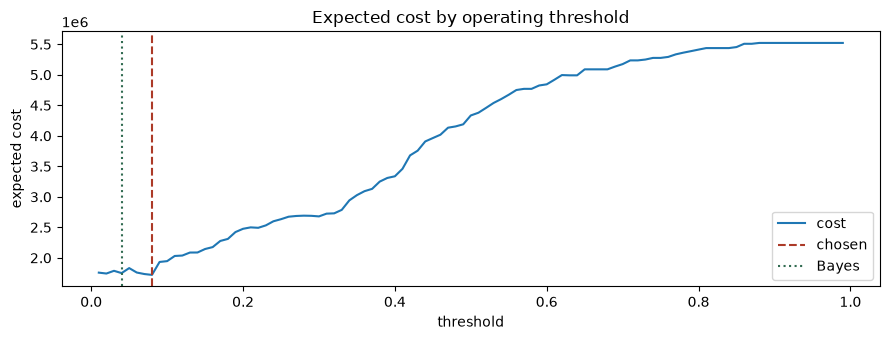

In [5]:
curve = pd.DataFrame(result["curve"])
ax = curve.plot(x="threshold", y="cost", figsize=(9, 3.5), legend=False,
                title="Expected cost by operating threshold")
ax.axvline(result["threshold"], color="#AC3A28", ls="--", label="chosen")
ax.axvline(result["bayes_optimal_threshold"], color="#316B51", ls=":", label="Bayes")
ax.set_ylabel("expected cost"); ax.legend(); plt.tight_layout()

### And a second, operational threshold

Cost optimality and operational reality are different questions. A 24:1 asymmetry
correctly says "flag a lot of people" — which is right economics and a useless
work queue. The capacity threshold gives the dashboard a bounded watchlist.

In [6]:
print(capacity_threshold(oof))

{'capacity_pct': 0.2, 'employees_flagged': 235, 'threshold': 0.268}
